# **Amsterdam Listings Price Prediction from Images**

## Setup

In [ ]:
import pandas as pd
import numpy as np
import os
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## GPU stuff

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

## Load Training Dataset

In [ ]:
train_df = pd.read_csv("/kaggle/input/listings/train_listings.csv")
train_df['price'] = (
    train_df['price'].astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
train_df = train_df[(train_df['price'] >= 50) & (train_df['price'] <= 2000)]
train_df['log_price'] = np.log1p(train_df['price'])  # Optional: log price


In [ ]:
IMAGE_SIZE = (224, 224)
def download_and_preprocess(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize(IMAGE_SIZE)
        img_array = img_to_array(img)
        return preprocess_input(img_array)
    except:
        return None

# Only use rows with valid image URLs
train_df = train_df[train_df['picture_url'].notnull()]
tqdm.pandas()
train_df['image_array'] = train_df['picture_url'].progress_apply(download_and_preprocess)
train_df = train_df[train_df['image_array'].notnull()]


In [ ]:
# Save the images
np.save("/kaggle/working/all_images.npy", np.stack(train_df['image_array'].values))

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

## Trying ImageNet

In [ ]:
resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))

image_stack = np.stack(train_df['image_array'].values)
features = resnet.predict(image_stack, batch_size=32)


In [ ]:
X = features
y = train_df['log_price'].values  # or 'price' if not log-transformed

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32)


In [ ]:
log_preds = model.predict(X_val).flatten()
actual_prices = np.expm1(y_val)
predicted_prices = np.expm1(log_preds)

mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
r2 = r2_score(actual_prices, predicted_prices)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")


In [ ]:
base = ResNet50(
    weights="imagenet",        # ← ready‑made in TF/Keras
    include_top=False,         # drop the 1000‑way classifier
    pooling="avg",             # global‑average‑pool to 2048‑D vector
    input_shape=(224, 224, 3),
)
base.trainable = False         # freeze for the first phase

In [ ]:
from tensorflow.keras import Sequential, layers, optimizers, losses, metrics

model = Sequential(
    [
        base,
        layers.Dropout(0.2),
        layers.Dense(1, activation="linear"),   # ← regression head
    ]
)

model.compile(
    optimizer=optimizers.Adam(0.001),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.RootMeanSquaredError(name="rmse"), "mae"],
)

In [ ]:
X = np.stack(train_df["image_array"].values).astype("float32")
y = train_df["log_price"].values        # you already log‑transformed 💡

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
    .shuffle(1024)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_rmse", patience=5, restore_best_weights=True)
]

# Phase 1 – train only the 1‑unit regressor
history_1 = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

# Phase 2 – unfreeze last 2‑3 ResNet blocks for fine‑tuning
base.trainable = True
for layer in base.layers[:-20]:      # keep majority frozen
    layer.trainable = False

model.compile(                       # lower LR for fine‑tuning!
    optimizer=optimizers.Adam(1e-4),
    loss=losses.MeanSquaredError(),
    metrics=[metrics.RootMeanSquaredError(name="rmse"), "mae"],
)

history_2 = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)

In [ ]:
pred_log = model.predict(val_ds).ravel()
pred_price = np.expm1(pred_log)       # inverse of log1p
true_price = np.expm1(y_val)

# print("MAE ($):", mean_absolute_error(true_price, pred_price))

mae = mean_absolute_error(true_price, pred_price)
rmse = np.sqrt(mean_squared_error(true_price, pred_price))
r2 = r2_score(true_price, pred_price)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")


### Why do images alone seem to struggle to predict Airbnb price?

- Location: not visible
- Demand: not visible
- Amenities: partially visible
- Listings of capacity (beds, bathrooms): not visible
- Host strategy (dynamic pricing, cleaning fees): not visible
- Photo quality: visible

Only 1 signal explains why there is a poor r2 score!

## Hybrid model (by also using tabular features)

In [2]:
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
import requests
import tensorflow as tf
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, Concatenate, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.losses import Huber
from keras.callbacks import ReduceLROnPlateau
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Define paths
IMAGE_SAVE_PATH = "/kaggle/working/preprocessed_images.npy"
INDICES_SAVE_PATH = "/kaggle/working/image_indices.npy"
IMAGE_SIZE = (224, 224)

def download_and_preprocess(url):
    try:
        response = requests.get(url, timeout=5)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img = img.resize(IMAGE_SIZE)
        img_array = img_to_array(img)
        return preprocess_input(img_array)
    except:
        return None

def save_preprocessed_images(df, image_path=IMAGE_SAVE_PATH, indices_path=INDICES_SAVE_PATH):
    """Save preprocessed images and their indices"""
    # Save the image arrays
    np.save(image_path, np.stack(df['image_array'].values))
    # Save the corresponding DataFrame indices
    np.save(indices_path, df.index.values)
    print(f"Saved {len(df)} preprocessed images")

def load_preprocessed_images(df, image_path=IMAGE_SAVE_PATH, indices_path=INDICES_SAVE_PATH):
    """Load preprocessed images and match them with the DataFrame"""
    # Load images and indices
    image_arrays = np.load(image_path)
    saved_indices = np.load(indices_path)
    
    # Create a dictionary mapping indices to image arrays
    image_dict = dict(zip(saved_indices, image_arrays))
    
    # Create new column by mapping current indices to saved images
    df['image_array'] = df.index.map(image_dict)
    
    # Filter rows where image loading was successful
    df = df[df['image_array'].notnull()]
    print(f"Loaded {len(df)} preprocessed images")
    return df



### Load training data

In [4]:
# Load data
train_df = pd.read_csv("/kaggle/input/listings/train_listings.csv")

# Preprocess prices
train_df['price'] = (
    train_df['price'].astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
train_df = train_df[(train_df['price'] >= 50) & (train_df['price'] <= 2000)]
train_df['log_price'] = np.log1p(train_df['price'])

# Handle images - either download or load saved
if Path(IMAGE_SAVE_PATH).exists():
    print("Loading preprocessed images from disk")
    train_df = train_df[train_df['picture_url'].notnull()]
    train_df = load_preprocessed_images(train_df)
else:
    print("Downloading and preprocessing images")
    train_df = train_df[train_df['picture_url'].notnull()]
    tqdm.pandas()
    train_df['image_array'] = train_df['picture_url'].progress_apply(download_and_preprocess)
    train_df = train_df[train_df['image_array'].notnull()]
    save_preprocessed_images(train_df)

image_arrays = np.stack(train_df['image_array'].values)

Loading preprocessed images from disk
Loaded 5020 preprocessed images


### Load testing data

In [5]:
# === Constants for test set ===
TEST_IMAGE_SAVE_PATH = "/kaggle/working/test_preprocessed_images.npy"
TEST_INDICES_SAVE_PATH = "/kaggle/working/test_image_indices.npy"
IMAGE_SIZE = (224, 224)

def save_preprocessed_images_test(df, image_path=TEST_IMAGE_SAVE_PATH, indices_path=TEST_INDICES_SAVE_PATH):
    """Save preprocessed test images and their indices"""
    np.save(image_path, np.stack(df['image_array'].values))
    np.save(indices_path, df.index.values)
    print(f"Saved {len(df)} preprocessed test images")

def load_preprocessed_images_test(df, image_path=TEST_IMAGE_SAVE_PATH, indices_path=TEST_INDICES_SAVE_PATH):
    """Load preprocessed test images and match with test DataFrame"""
    image_arrays = np.load(image_path)
    saved_indices = np.load(indices_path)
    image_dict = dict(zip(saved_indices, image_arrays))
    df['image_array'] = df.index.map(image_dict)
    df = df[df['image_array'].notnull()]
    print(f"Loaded {len(df)} preprocessed test images")
    return df

# === Load test data ===
test_df = pd.read_csv("/kaggle/input/listings/test_listings.csv")

# Preprocess price column if needed (depends on your task)
test_df['price'] = (
    test_df['price'].astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)
test_df = test_df[(test_df['price'] >= 50) & (test_df['price'] <= 2000)]
test_df['log_price'] = np.log1p(test_df['price'])

# Handle test images
if Path(TEST_IMAGE_SAVE_PATH).exists():
    print("Loading preprocessed test images from disk")
    test_df = test_df[test_df['picture_url'].notnull()]
    test_df = load_preprocessed_images_test(test_df)
else:
    print("Downloading and preprocessing test images")
    test_df = test_df[test_df['picture_url'].notnull()]
    tqdm.pandas()
    test_df['image_array'] = test_df['picture_url'].progress_apply(download_and_preprocess)
    test_df = test_df[test_df['image_array'].notnull()]
    save_preprocessed_images_test(test_df)

# Final image array
test_image_arrays = np.stack(test_df['image_array'].values)

Loading preprocessed test images from disk
Loaded 1257 preprocessed test images


In [6]:
# Reset index after filtering
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Select relevant tabular features
tabular_features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds',  # Property characteristics
    'minimum_nights', 'maximum_nights',  # Booking rules
    'number_of_reviews', 'review_scores_rating',  # Popularity and reviews
    'latitude', 'longitude',  # Location
    'property_type', 'room_type',  # Categorical features
    'host_is_superhost', 'instant_bookable'  # Host and booking features
]

In [7]:
# Preprocess tabular data
X = train_df[tabular_features]
y = train_df['log_price']  # Using log price as target

X_test = test_df[tabular_features]
y_test = test_df['log_price']

In [8]:
# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Define preprocessing for numerical and categorical features
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 
                   'minimum_nights', 'maximum_nights', 'number_of_reviews',
                   'review_scores_rating', 'latitude', 'longitude']
numeric_transformer = StandardScaler()

categorical_features = ['property_type', 'room_type', 'host_is_superhost', 'instant_bookable']
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [10]:
# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# And the testing data
X_test_processed = preprocessor.fit_transform(X_test)

In [11]:
# Get the indices used for train/val split
train_indices = X_train.index
val_indices = X_val.index

# and test
test_indices = X_test.index

# Load the preprocessed images
image_arrays = np.stack(train_df['image_array'].values)

# Select images using the correct indices
X_train_images = image_arrays[train_indices]
X_val_images = image_arrays[val_indices]
X_test_images = test_image_arrays[test_indices]

In [12]:
# Get the shape of processed tabular data
tabular_input_shape = X_train_processed.shape[1]

# just in case...
test_tabular_input_shape = X_test_processed.shape[1]

In [13]:
# Handle missing values in numeric features
numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_features] = numeric_imputer.fit_transform(X_train[numeric_features])
X_val[numeric_features] = numeric_imputer.transform(X_val[numeric_features])
X_test[numeric_features] = numeric_imputer.transform(X_test[numeric_features])

# Update the preprocessor to handle missing values
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [14]:
# Process the data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()
    X_test_processed = X_test_processed.toarray()

In [15]:
# Enhanced model architecture
def create_improved_model(tabular_input_shape):
    # Image branch
    image_input = Input(shape=(224, 224, 3))
    base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')
    base_model.trainable = False  # Start with frozen, consider unfreezing later
    x = base_model(image_input)
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    # Tabular branch
    tab_input = Input(shape=(tabular_input_shape,))
    y = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(tab_input)
    y = BatchNormalization()(y)
    y = Dropout(0.3)(y)
    y = Dense(64, activation='relu')(y)
    
    # Combined
    combined = Concatenate()([x, y])
    z = Dense(64, activation='relu')(combined)
    z = BatchNormalization()(z)
    z = Dropout(0.2)(z)
    z = Dense(32, activation='relu')(z)
    output = Dense(1)(z)
    
    model = Model(inputs=[image_input, tab_input], outputs=output)
    
    optimizer = Adam(learning_rate=0.01)
    model.compile(optimizer=optimizer, 
                 loss=tf.keras.losses.Huber(),
                 metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"),
                          tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model

# Create model
model = create_improved_model(X_train_processed.shape[1])

I0000 00:00:1752609704.360978    2645 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [16]:
# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True,
    mode='min',  # Explicitly looking for a lower val_mae
    verbose=1     # Helpful to log when early stopping triggers
)

In [17]:
# Optionally add Reduce LR when learning plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=3,
    verbose=1,
    mode='min',
    min_lr=1e-6
)

In [18]:
# Add early stopping
# early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

# Train with validation
history = model.fit(
    [X_train_images, X_train_processed], y_train,
    validation_data=([X_val_images, X_val_processed], y_val),
    epochs=50,  # More epochs with early stopping
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50


I0000 00:00:1752609735.061962    2699 service.cc:148] XLA service 0x14487850 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752609735.061994    2699 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752609737.449739    2699 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/126 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 3.4291 - mae: 3.8928 - rmse: 4.0849   

I0000 00:00:1752609749.102349    2699 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/126 ━━━━━━━━━━━━━━━━━━━━ 68s 269ms/step - loss: 1.0435 - mae: 1.3723 - rmse: 1.8087 - val_loss: 0.4153 - val_mae: 0.6837 - val_rmse: 0.8356 - learning_rate: 0.0100
Epoch 2/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.3386 - mae: 0.5750 - rmse: 0.7302 - val_loss: 0.1955 - val_mae: 0.3747 - val_rmse: 0.4873 - learning_rate: 0.0100
Epoch 3/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.2499 - mae: 0.4686 - rmse: 0.6026 - val_loss: 0.1833 - val_mae: 0.3748 - val_rmse: 0.4820 - learning_rate: 0.0100
Epoch 4/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.1982 - mae: 0.4049 - rmse: 0.5203 - val_loss: 0.1618 - val_mae: 0.3688 - val_rmse: 0.4624 - learning_rate: 0.0100
Epoch 5/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.1666 - mae: 0.3737 - rmse: 0.4810 - val_loss: 0.1244 - val_mae: 0.3114 - val_rmse: 0.3983 - learning_rate: 0.0100
Epoch 6/50
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.1400 - mae: 0.3467 - rmse: 0.4454 - val_loss: 0.0976 - val_ma

126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step

Training Set Metrics:
R² Score: 0.7209
MAE: $60.64
RMSE: $120.45
MAPE: 20.19%
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step

Validation Set Metrics:
R² Score: 0.5937
MAE: $66.86
RMSE: $122.19
MAPE: 23.93%
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


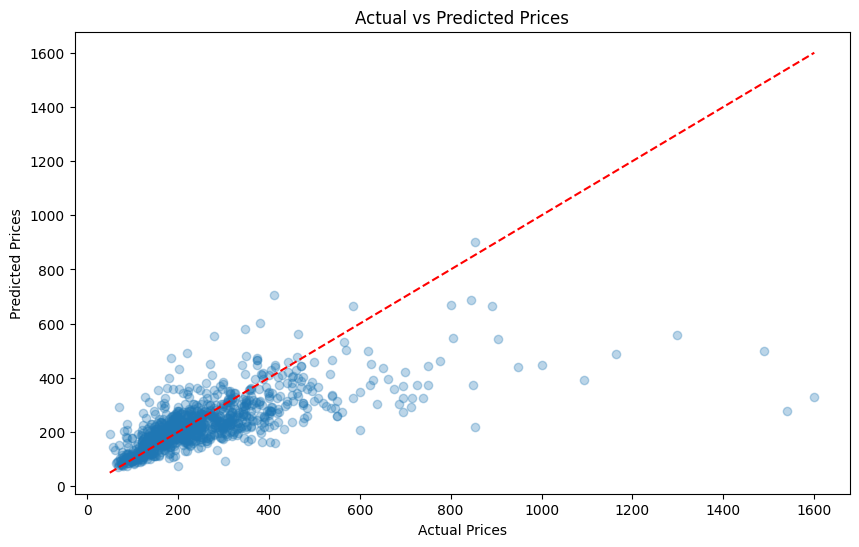

In [19]:
def evaluate_model(model, X_images, X_tabular, y_true, set_name="Validation"):
    """Calculate and print evaluation metrics"""
    # Get predictions
    y_pred = model.predict([X_images, X_tabular]).flatten()
    
    # Convert from log price to actual price
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred)
    
    # Calculate metrics
    metrics = {
        'r2': r2_score(y_true, y_pred),
        'mae': mean_absolute_error(y_true_actual, y_pred_actual),
        'rmse': np.sqrt(mean_squared_error(y_true_actual, y_pred_actual)),
        'mape': np.mean(np.abs((y_true_actual - y_pred_actual) / y_true_actual)) * 100
    }
    
    # Print results
    print(f"\n{set_name} Set Metrics:")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"MAE: ${metrics['mae']:.2f}")
    print(f"RMSE: ${metrics['rmse']:.2f}")
    print(f"MAPE: {metrics['mape']:.2f}%")
    
    return metrics

# Evaluate on both training and validation sets
train_metrics = evaluate_model(
    model, 
    X_train_images, 
    X_train_processed, 
    y_train, 
    "Training"
)

val_metrics = evaluate_model(
    model, 
    X_val_images, 
    X_val_processed, 
    y_val, 
    "Validation"
)

# Additional visualization
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(title)
    plt.show()

# Get validation predictions for plotting
val_preds = model.predict([X_val_images, X_val_processed]).flatten()
val_actuals = np.expm1(y_val)
val_preds_actual = np.expm1(val_preds)

plot_predictions(val_actuals, val_preds_actual, "Actual vs Predicted Prices")

## Test set evaluation

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step

Test Set Metrics:
R² Score: 0.5916
MAE: $65.96
RMSE: $119.10
MAPE: 25.05%
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


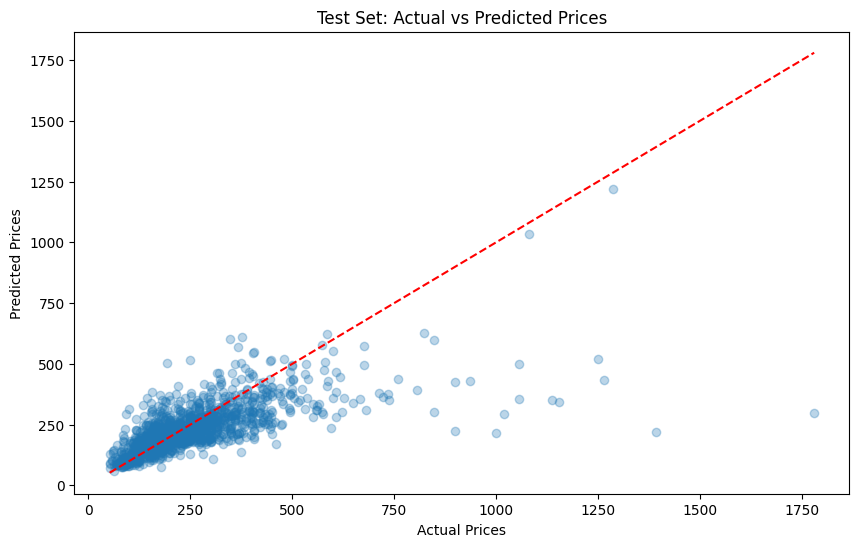

In [20]:
test_metrics = evaluate_model(
    model, 
    X_test_images, 
    X_test_processed, 
    y_test, 
    "Test"
)

test_preds = model.predict([X_test_images, X_test_processed]).flatten()
test_actuals = np.expm1(y_test)
test_preds_actual = np.expm1(test_preds)

plot_predictions(test_actuals, test_preds_actual, "Test Set: Actual vs Predicted Prices")
